<a href="https://colab.research.google.com/github/Eelaf-Adam/PCA_PAIR_TEAM-_4-/blob/main/PCA_Formative_1%5BPCA_PAIR_TEAM__4_%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative Assignment: Advanced Linear Algebra (PCA)
 In this assignment our team performed dimensionality reduction using PCA on an Africanized dataset presenting **Malaria Cases** accross the continent.

## The Data Source can be found here:
https://www.kaggle.com/datasets/lydia70/malaria-in-africa


### Link to the Github Repo:
https://github.com/Eelaf-Adam/PCA_PAIR_TEAM-_4-.git



### Step 0: Load the Dataset
Import the libraries, load the data and display the number of rows and columns, also apply encoding



In [8]:
# Importing the libararies needed for teh analysis

import numpy as np
import matplotlib.pyplot as plt
import csv
import time

# Loading the malaria dataset from the CSV file
with open('DatasetAfricaMalaria.csv', encoding='utf-8') as file:
  data = list(csv.reader(file))

# Display basic information on the dataset
print("Rows:", len(data) -1)
print("Columns:", len(data[0]))
print("Column names:", data[0])

Rows: 594
Columns: 27
Column names: ['Country Name', 'Year', 'Country Code', 'Incidence of malaria (per 1,000 population at risk)', 'Malaria cases reported', 'Use of insecticide-treated bed nets (% of under-5 population)', 'Children with fever receiving antimalarial drugs (% of children under age 5 with fever)', 'Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)', 'People using safely managed drinking water services (% of population)', 'People using safely managed drinking water services, rural (% of rural population)', 'People using safely managed drinking water services, urban (% of urban population)', 'People using safely managed sanitation services (% of population)', 'People using safely managed sanitation services, rural (% of rural population)', 'People using safely managed sanitation services, urban  (% of urban population)', 'Rural population (% of total population)', 'Rural population growth (annual %)', 'Urban population (% of total popula

### Step 1: Handle Missing Values and Non Numeric Columns
Select numeric columns, then check missing values in each column, after that select the columns we will use for the PCA. Also, it replaces the blank values with NAN and convert the data to float. Finally, replace the missing vlaues with the mean of each column and confirm that there are no missing values remaining.

In [9]:
# Convert the dataset into a NumPy array
headers = np.array(data[0])
rows = np.array(data[1:], dtype= object)
print(rows.shape)

# Display the column names and their index numbers
for i, name in enumerate(headers):
  print(i, name)

# Select the numeric columns
metadata = rows[:, :3]
numeric_data = rows[:, 3:]

# Check the missing values in each column
missing= (numeric_data == '')
print("These are missing value per column:")
print(np.sum(missing, axis=0))
for name, count in zip(headers[3:], np.sum(missing, axis=0)):
  print(name, ":",count)

# Select the columns that will be used for PCA
selected_indices = [3,4] + list(range(14,24))
selected_data= rows[:, selected_indices]
selected_headers = headers[selected_indices]

# Replace blank values with NaN and convert the data to float
selected_data[selected_data == ''] = np.nan
selected_data = selected_data.astype(float)

# Replace missing values with the mean of each column
col_means = np.nanmean(selected_data, axis=0)
missing= np.where(np.isnan(selected_data))
selected_data[missing] = col_means[missing[1]]

# Confirm that there are no missing values remaining
print("Missing values after doing imputation:", np.isnan(selected_data).sum())
print("The final shape:", selected_data.shape)

(594, 27)
0 Country Name
1 Year
2 Country Code
3 Incidence of malaria (per 1,000 population at risk)
4 Malaria cases reported
5 Use of insecticide-treated bed nets (% of under-5 population)
6 Children with fever receiving antimalarial drugs (% of children under age 5 with fever)
7 Intermittent preventive treatment (IPT) of malaria in pregnancy (% of pregnant women)
8 People using safely managed drinking water services (% of population)
9 People using safely managed drinking water services, rural (% of rural population)
10 People using safely managed drinking water services, urban (% of urban population)
11 People using safely managed sanitation services (% of population)
12 People using safely managed sanitation services, rural (% of rural population)
13 People using safely managed sanitation services, urban  (% of urban population)
14 Rural population (% of total population)
15 Rural population growth (annual %)
16 Urban population (% of total population)
17 Urban population growth (a

In [10]:
# Verify which columns are used to implement PCA
indices = [i for i in range(len(headers)) if i in selected_indices]

for i in indices:
    print(i, headers[i])

3 Incidence of malaria (per 1,000 population at risk)
4 Malaria cases reported
14 Rural population (% of total population)
15 Rural population growth (annual %)
16 Urban population (% of total population)
17 Urban population growth (annual %)
18 People using at least basic drinking water services (% of population)
19 People using at least basic drinking water services, rural (% of rural population)
20 People using at least basic drinking water services, urban (% of urban population)
21 People using at least basic sanitation services (% of population)
22 People using at least basic sanitation services, rural (% of rural population)
23 People using at least basic sanitation services, urban  (% of urban population)


### Step 2: Load and Standardize the Data
Calculate the mean and the standard deviation of each column, ensured each feature has a mean of 0 and a standard deviation of 1.

The code implements standardization strictly based on the image below

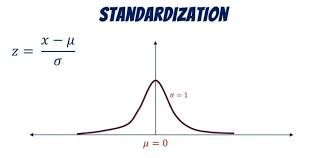


In [11]:
# Calculate the mean and standard deviation of each column
mean = np.mean(selected_data, axis=0)
std = np.std(selected_data, axis=0)

# Standardize the data so each feature has mean 0 and standard deviation 1
standardised_data = (selected_data - mean) / std

# Display the first 6 standardized data
standardised_data[:6]

# Check that standardization was successful
print("Means:", np.round(np.mean(standardised_data, axis=0),2))
print("Standard deviations:", np.round(np.std(standardised_data, axis=0),2))

Means: [-0.  0. -0.  0.  0.  0. -0.  0. -0. -0.  0. -0.]
Standard deviations: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [12]:
# Get the number of observations (rows)
n= standardised_data.shape[0]

# Calculate the covariance matrix of the standardized data
cov_matrix = (standardised_data.T @ standardised_data) / (n-1)

# Display the covariance matrix
cov_matrix

array([[ 1.00168634,  0.28899539,  0.24544679,  0.38713922, -0.24545029,
         0.30961969, -0.36891253, -0.31348426, -0.39901543, -0.44098387,
        -0.37580098, -0.42594845],
       [ 0.28899539,  1.00168634,  0.21333737,  0.24023442, -0.21334606,
         0.25243049, -0.23244903, -0.18060952, -0.16759034, -0.17510584,
        -0.11434487, -0.20858905],
       [ 0.24544679,  0.21333737,  1.00168634,  0.6527522 , -1.00168633,
         0.22866807, -0.6262459 , -0.27439309, -0.26699267, -0.51359092,
        -0.26661431, -0.44049159],
       [ 0.38713922,  0.24023442,  0.6527522 ,  1.00168634, -0.6527523 ,
         0.33022238, -0.59193849, -0.40540788, -0.39962352, -0.51458269,
        -0.38221811, -0.441068  ],
       [-0.24545029, -0.21334606, -1.00168633, -0.6527523 ,  1.00168634,
        -0.22867207,  0.62624836,  0.27439493,  0.26699783,  0.51359345,
         0.26661723,  0.4404946 ],
       [ 0.30961969,  0.25243049,  0.22866807,  0.33022238, -0.22867207,
         1.00168634, -

#### Why we need to compute a covariance matrix?

The covariance matrix helps us see how different feautures in our dataset are connected. First, it can show whether malaria cases change together with things like population, access to clean water, or sanitation. Second, we also need it because PCA uses these relationships to find where most of the important differences in the data are. This helps us reduce the number of features while keeping as much useful information as possible.

### Step 4: Perform Eigendecomposition
Eigendecomposition finds the important directions hidden in the covariance matrix.

In [13]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)  # Perform eigendecomposition
eigenvalues, eigenvectors

(array([6.22773990e+00, 1.71035174e+00, 1.06016939e+00, 7.86875115e-01,
        6.94145848e-01, 6.16741132e-01, 3.97794808e-01, 2.39871035e-01,
        1.68529550e-01, 1.09763808e-01, 8.25375781e-03, 1.07085738e-08]),
 array([[-2.14325736e-01,  5.01910189e-02,  4.60076582e-01,
          4.73600325e-01, -5.52130148e-01, -3.13874725e-01,
          2.71783876e-01, -1.85518238e-01,  2.45014333e-02,
         -5.12203265e-02, -2.65562438e-02,  2.98256056e-07],
        [-1.26872920e-01, -1.09249606e-01,  7.89357412e-01,
         -1.65219560e-01,  2.33068533e-01,  5.07738166e-01,
         -5.54544980e-02,  1.41132261e-02, -7.46265352e-02,
         -2.31897822e-02,  9.21428714e-03,  6.03757004e-06],
        [-2.66606885e-01, -5.45580233e-01, -1.30793410e-01,
         -1.50390844e-02,  4.11954817e-02,  2.40317547e-02,
          2.50139429e-01,  4.70382049e-02,  8.34234625e-02,
         -1.76226374e-01,  9.41306729e-02,  7.07104784e-01],
        [-2.78568705e-01, -3.12458467e-01,  4.74583448e-02,

### Step 5: Sort Principal Components
Sorting the principal components ranks the eigenvalues by how much variance they capture from the data.


In [14]:
# Sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]

# Sort eigenvectors accordingly
sorted_eigenvectors = eigenvectors[:, sorted_indices]

# Sort the eigenvalues
sorted_eigenvalues = eigenvalues[sorted_indices]

sorted_eigenvalues, sorted_eigenvectors

(array([6.22773990e+00, 1.71035174e+00, 1.06016939e+00, 7.86875115e-01,
        6.94145848e-01, 6.16741132e-01, 3.97794808e-01, 2.39871035e-01,
        1.68529550e-01, 1.09763808e-01, 8.25375781e-03, 1.07085738e-08]),
 array([[-2.14325736e-01,  5.01910189e-02,  4.60076582e-01,
          4.73600325e-01, -5.52130148e-01, -3.13874725e-01,
          2.71783876e-01, -1.85518238e-01,  2.45014333e-02,
         -5.12203265e-02, -2.65562438e-02,  2.98256056e-07],
        [-1.26872920e-01, -1.09249606e-01,  7.89357412e-01,
         -1.65219560e-01,  2.33068533e-01,  5.07738166e-01,
         -5.54544980e-02,  1.41132261e-02, -7.46265352e-02,
         -2.31897822e-02,  9.21428714e-03,  6.03757004e-06],
        [-2.66606885e-01, -5.45580233e-01, -1.30793410e-01,
         -1.50390844e-02,  4.11954817e-02,  2.40317547e-02,
          2.50139429e-01,  4.70382049e-02,  8.34234625e-02,
         -1.76226374e-01,  9.41306729e-02,  7.07104784e-01],
        [-2.78568705e-01, -3.12458467e-01,  4.74583448e-02,

In [15]:
print("Feature Loadings:")
print()

for i, feature in enumerate(selected_headers):
    print(f"{feature:<80}", end=" ")

    for pc in range(sorted_eigenvectors.shape[1]):
        print(f"PC{pc+1}: {sorted_eigenvectors[i, pc]:.3f}", end="  ")

    print()

Feature Loadings:

Incidence of malaria (per 1,000 population at risk)                              PC1: -0.214  PC2: 0.050  PC3: 0.460  PC4: 0.474  PC5: -0.552  PC6: -0.314  PC7: 0.272  PC8: -0.186  PC9: 0.025  PC10: -0.051  PC11: -0.027  PC12: 0.000  
Malaria cases reported                                                           PC1: -0.127  PC2: -0.109  PC3: 0.789  PC4: -0.165  PC5: 0.233  PC6: 0.508  PC7: -0.055  PC8: 0.014  PC9: -0.075  PC10: -0.023  PC11: 0.009  PC12: 0.000  
Rural population (% of total population)                                         PC1: -0.267  PC2: -0.546  PC3: -0.131  PC4: -0.015  PC5: 0.041  PC6: 0.024  PC7: 0.250  PC8: 0.047  PC9: 0.083  PC10: -0.176  PC11: 0.094  PC12: 0.707  
Rural population growth (annual %)                                               PC1: -0.279  PC2: -0.312  PC3: 0.047  PC4: -0.028  PC5: -0.213  PC6: -0.209  PC7: -0.853  PC8: 0.008  PC9: 0.016  PC10: 0.070  PC11: -0.013  PC12: -0.000  
Urban population (% of total population)

### Step 6: Dynamically select the number of principal components based on explained variance

Computing the explained variance shows us which principal components contain the most information

#### Step 6.1: Calculate the total variance explained by each principal component

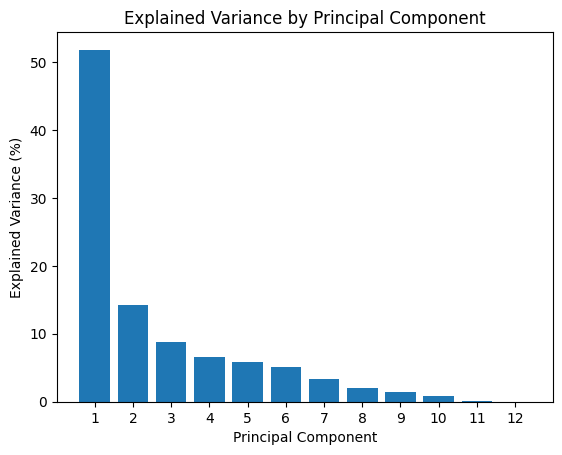

In [16]:
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)

components = np.arange(1, len(explained_variance_ratio) + 1)

plt.bar(components, explained_variance_ratio * 100)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")
plt.title("Explained Variance by Principal Component")

plt.xticks(components)
plt.show()

#### Step 6.2: Test different variance thresholds

In [17]:
# Test different total explained variance thresholds
thresholds = [0.80, 0.90, 0.95, 0.99]

cumulative_variance = np.cumsum(explained_variance_ratio)

for threshold in thresholds:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{threshold:.0%}: {n_components} components")

80%: 4 components
90%: 6 components
95%: 7 components
99%: 9 components


#### Step 6.3: Plot the variance depending on the number of principal components

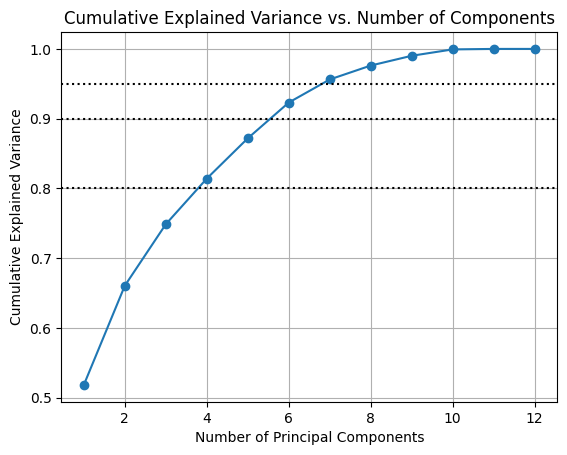

In [18]:
components = np.arange(1, len(cumulative_variance) + 1)

plt.plot(components, cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs. Number of Components")
plt.axhline(0.80, linestyle='dotted', label='80%', color='black')
plt.axhline(0.90, linestyle='dotted', label='90%', color='black')
plt.axhline(0.95, linestyle='dotted', label='95%', color='black')
plt.grid(True)
plt.show()

### Step 7: Project Data onto Principal Components
The original standardized data is projected onto the selected principal components to create a lower-dimensional representation of the
dataset.

In [19]:
# Step 7: Project Data onto Principal Components
n_components = 7
principal_components = sorted_eigenvectors[:, :n_components]
reduced_data = np.dot(standardised_data, principal_components)
reduced_data[:5]

array([[ 5.02193507, -0.13290513,  0.23611454, -0.59236191,  0.2498313 ,
        -0.43616966,  0.46038227],
       [-1.68258623,  2.00715939,  0.55793055, -1.49500908, -0.9973457 ,
        -0.52769161, -0.25299978],
       [-1.96389819,  0.69932302,  0.12429587,  1.67220291, -0.78427257,
        -0.63008386,  0.11046115],
       [ 2.83925193,  0.97712332, -0.19163816, -0.75747558,  1.47701331,
        -0.62024292,  1.2362825 ],
       [-2.84932746, -0.29894771,  0.26380749,  0.5075237 , -0.54244362,
        -1.73622132,  0.778047  ]])



### Step 8: Output the Reduced Data
Display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [20]:
# Step 8: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')
print('First 5 rows of reduced data')
reduced_data[:5]

Reduced Data Shape: (594, 7)
First 5 rows of reduced data


array([[ 5.02193507, -0.13290513,  0.23611454, -0.59236191,  0.2498313 ,
        -0.43616966,  0.46038227],
       [-1.68258623,  2.00715939,  0.55793055, -1.49500908, -0.9973457 ,
        -0.52769161, -0.25299978],
       [-1.96389819,  0.69932302,  0.12429587,  1.67220291, -0.78427257,
        -0.63008386,  0.11046115],
       [ 2.83925193,  0.97712332, -0.19163816, -0.75747558,  1.47701331,
        -0.62024292,  1.2362825 ],
       [-2.84932746, -0.29894771,  0.26380749,  0.5075237 , -0.54244362,
        -1.73622132,  0.778047  ]])

### Step 9: Visualize Before and After PCA
Plot the original data and the data after PCA and compare the reduction in dimensions visually.

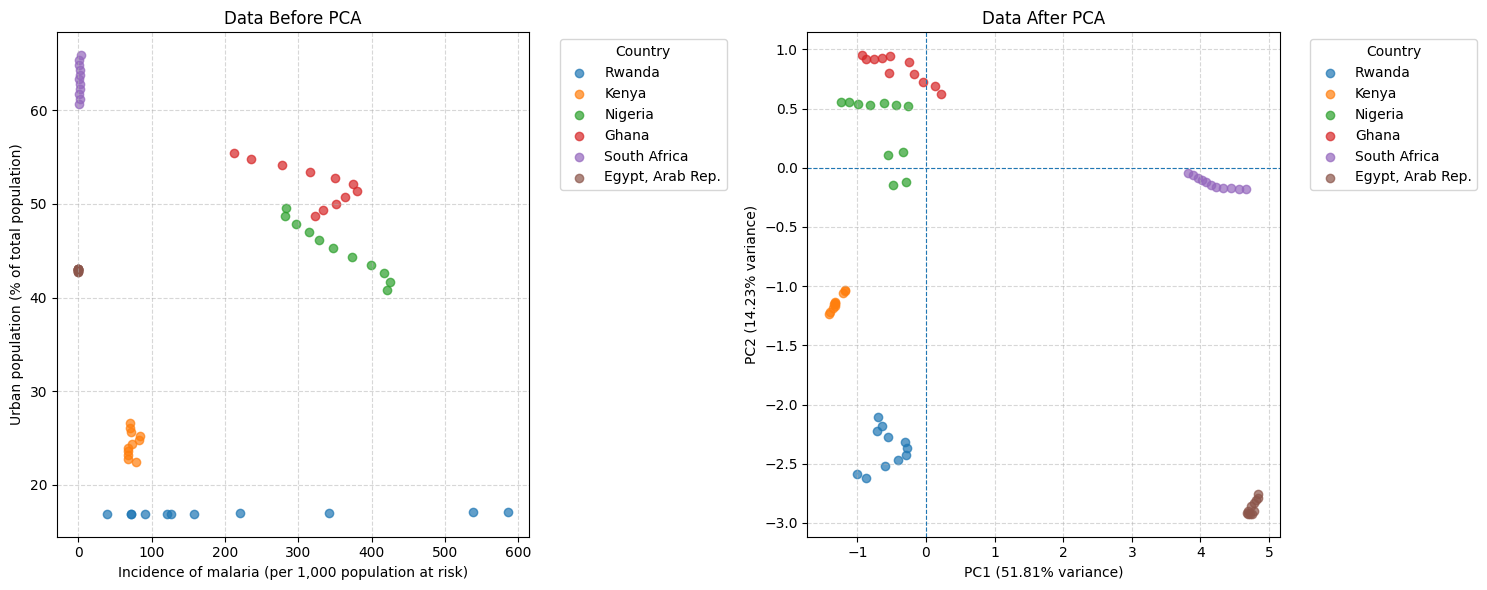

In [21]:
# Step 9: Visualize Before and After PCA by Selected Countries

# Get the country for each observation
countries = rows[:, 0]

# Select a limited number of countries
selected_countries = [
    "Rwanda",
    "Kenya",
    "Nigeria",
    "Ghana",
    "South Africa",
    "Egypt, Arab Rep."
]

# Select two original features
feat_x_idx = 0   # Incidence of malaria
feat_y_idx = 4   # People using at least basic drinking water services, rural

x_label = selected_headers[feat_x_idx]
y_label = selected_headers[feat_y_idx]

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Before PCA
for country in selected_countries:

    mask = countries == country

    ax[0].scatter(
        selected_data[mask, feat_x_idx],
        selected_data[mask, feat_y_idx],
        alpha=0.7,
        label=country
    )

ax[0].set_title('Data Before PCA')
ax[0].set_xlabel(x_label)
ax[0].set_ylabel(y_label)
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')

# After PCA
for country in selected_countries:

    mask = countries == country

    ax[1].scatter(
        reduced_data[mask, 0],
        reduced_data[mask, 1],
        alpha=0.7,
        label=country
    )

ax[1].axhline(0, linestyle='--', linewidth=0.8)
ax[1].axvline(0, linestyle='--', linewidth=0.8)

ax[1].set_title('Data After PCA')
ax[1].set_xlabel(
    f'PC1 ({explained_variance_ratio[0] * 100:.2f}% variance)'
)
ax[1].set_ylabel(
    f'PC2 ({explained_variance_ratio[1] * 100:.2f}% variance)'
)
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Step 10: Benchmarking and Performance Optimization

Benchmarks a vectorized Numpy PCA pipeline. The dataset is repeated to simulate a much larger dataset while keeping the same African malaria and demographic infrastrcture feature structure.

In [22]:
#Step 10: Perform Benchmark Optimization for larger dataset

repeat_count = 100
large_data = np.tile(standardised_data, (repeat_count, 1))
print('Simulated large dataset shape:', large_data.shape)

start_time = time.perf_counter()

#Vectorized PCA pipeline
cov_large = (large_data.T @ large_data) / (large_data.shape[0] -1)
eigvals_large, eigvec_large = np.linalg.eigh(cov_large)
sort_idx = np.argsort(eigvals_large)[::-1]
reduced_large = large_data @ eigvec_large[:, sort_idx[:n_components]]

elapsed = time.perf_counter() - start_time

print(f"Benchmarking time: {elapsed:.4f} seconds")
print(f"Reduced large data shape: {reduced_large.shape}")

Simulated large dataset shape: (59400, 12)
Benchmarking time: 0.0126 seconds
Reduced large data shape: (59400, 7)


### PCA Interpetation



**1. Interpret the Visual you just created of the before and after PCA**

PCA combines information from the original features, which allows us to see the patterns and similarities between the countries in an easier way.   

**2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making**

After careful analysis of different thresholds, we decided to keep 7 Principal Components for these reasons:
- 7 components keeps over 0.95 variance while reducing the dimensionality by approximately 42%.
- the jump from 6 to 7 gave us an additional 5 percentage point while 7 to 9 only added 4%.
- keeping 4 to 6 Principal Components offered more aggressive compression but kept only 80-90% variance.

**3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?**

After applying dimentionality reduction we reduced the variables from 12 to 7 PCs. In this process we lost some specific information about individual indicators, such as exact malaria incidence or sanitation percentage of a country. e.g. if we're to use this to predict malaria risk, PCA might perserve the overall patterns related to malaria and population conditions, but some individual details that could help make a percise prediction may be lost.